--- Gerando Gráfico Comparativo: Histórico vs 18 Cenários vs LSTM ---
Sucesso! Gráfico salvo em: E:\Projetos\ABMS-WP\figuras\figura_10_comparacao_cenarios_clean_lstm.pdf


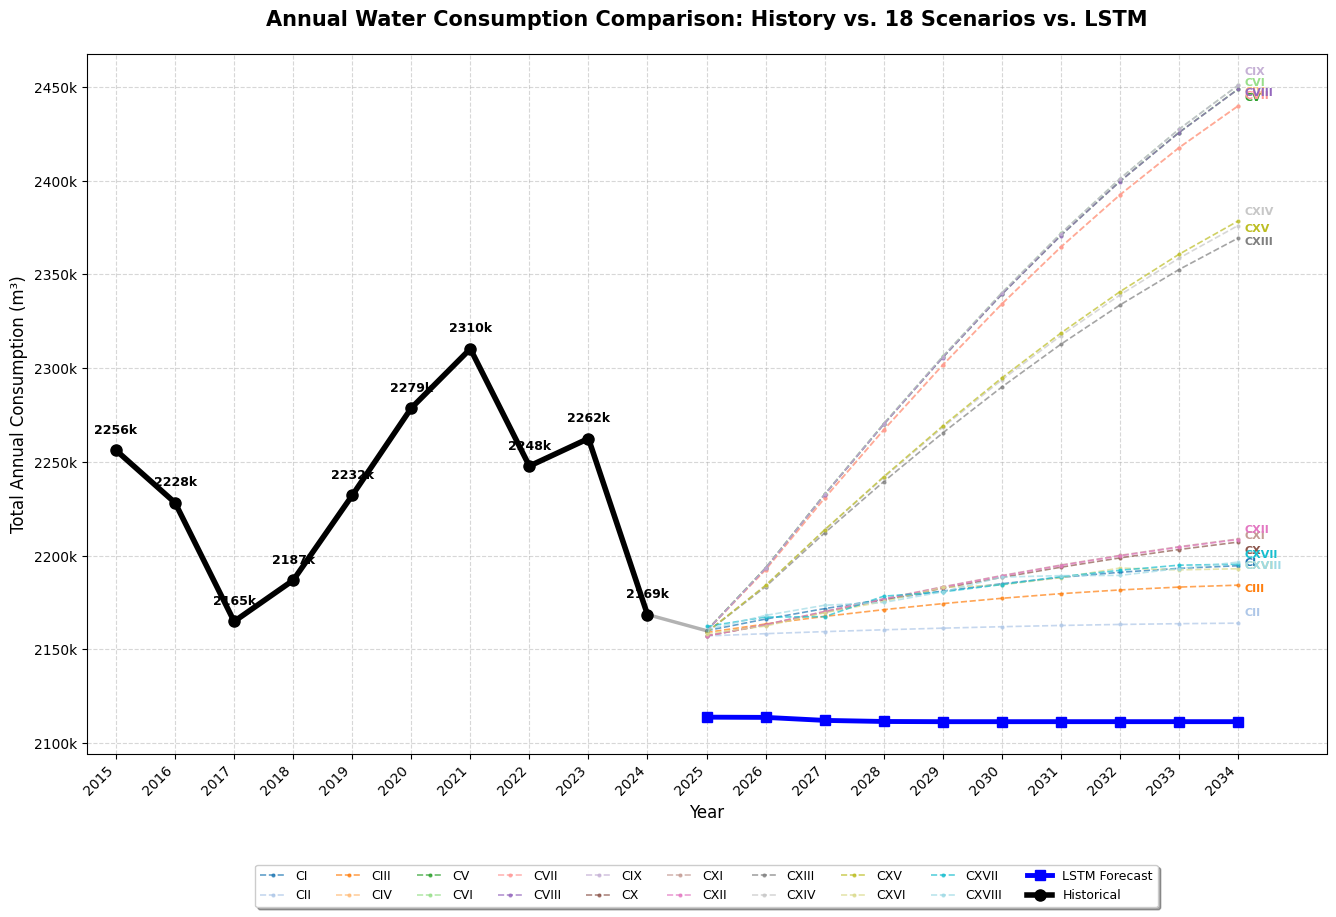

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurações e Caminhos
# ==========================================
# Base Paths (Mantenha o caminho ativo para o seu ambiente)
# Define the base project directory
# Uncomment the appropriate path for your environment
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# Arquivos de Entrada
SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv'
HISTORICAL_FILE = 'Tabela_consumo_Itapua_120m_por_mes.csv'
LSTM_FILE = 'previsoes_futuras_2025_2035.csv'

# Arquivo de Saída (PDF atualizado com "_lstm")
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figura_10_comparacao_cenarios_clean_lstm.pdf'

# Diretórios de busca
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')

def sum_yearly(df, date_col, value_cols):
    """ Agrega dados mensais para anuais """
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Gerando Gráfico Comparativo: Histórico vs 18 Cenários vs LSTM ---")

    # ==========================================
    # 2. Carregar e Preparar Dados
    # ==========================================
    
    # A. Cenários
    path_scen = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scen): path_scen = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    df_scen = pd.read_csv(path_scen, sep=';', decimal=',')
    if 'Mes' in df_scen.columns and 'Ano' in df_scen.columns:
        df_scen['Date'] = pd.to_datetime(df_scen['Ano'].astype(str) + '-' + df_scen['Mes'].astype(str) + '-01')
    
    scenario_cols = [c for c in df_scen.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scen = df_scen[df_scen['Date'] < pd.to_datetime('2035-01-01')]

    # B. Histórico
    path_hist = os.path.join(INPUT_DIR_INC, HISTORICAL_FILE)
    df_hist = pd.read_csv(path_hist, sep=';')
    df_hist['Date'] = pd.to_datetime(df_hist['data'])
    df_hist.rename(columns={'consumo': 'Hist'}, inplace=True)

    # C. LSTM
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    df_lstm = pd.read_csv(path_lstm)
    # Ajuste de data para o padrão datetime
    df_lstm['Date'] = pd.to_datetime(df_lstm['Data'], dayfirst=True)
    df_lstm.rename(columns={'Valor Previsto': 'LSTM'}, inplace=True)
    df_lstm = df_lstm[(df_lstm['Date'] >= '2025-01-01') & (df_lstm['Date'] <= '2034-12-31')]

    # Agregação Anual
    df_hist_sum = sum_yearly(df_hist, 'Date', ['Hist'])
    df_scen_sum = sum_yearly(df_scen, 'Date', scenario_cols)
    df_lstm_sum = sum_yearly(df_lstm, 'Date', ['LSTM'])

    # ==========================================
    # 3. Plotagem
    # ==========================================
    fig, ax = plt.subplots(figsize=(16, 10))

    # --- A. Linha de Conexão 2024 -> 2025 ---
    # Conecta o último ponto histórico ao primeiro ponto de um cenário base para continuidade visual
    last_hist = df_hist_sum.iloc[-1]
    first_scen_val = df_scen_sum.loc[df_scen_sum['Year'] == 2025, 'CI_Pop_Uniforme'].values[0]
    ax.plot([last_hist['Year'], 2025], [last_hist['Hist'], first_scen_val], 
            color='black', linestyle='-', linewidth=2.5, zorder=8, alpha=0.3)

    # --- B. Plotar 18 Cenários ---
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    offset_cycle = [(5, 0), (5, 5), (5, -5), (5, 8), (5, -8)]
    
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0]
        ax.plot(df_scen_sum['Year'], df_scen_sum[col], label=scen_id, color=colors[idx],
                linestyle='--', linewidth=1.2, alpha=0.7, marker='.', markersize=4)
        
        # Rótulo ID no final da linha
        last_y = df_scen_sum['Year'].iloc[-1]
        last_v = df_scen_sum[col].iloc[-1]
        ax.annotate(scen_id, (last_y, last_v), xytext=offset_cycle[idx % 5], 
                    textcoords="offset points", fontsize=8, color=colors[idx], fontweight='bold')

    # --- C. Plotar LSTM ---
    # Linha em destaque (ex: Azul escuro ou Vermelho) para diferenciar do Histórico (Preto)
    ax.plot(df_lstm_sum['Year'], df_lstm_sum['LSTM'], label='LSTM Forecast', color='blue',
            linestyle='-', linewidth=3.5, marker='s', markersize=7, zorder=11)

    # --- D. Plotar Histórico ---
    ax.plot(df_hist_sum['Year'], df_hist_sum['Hist'], label='Historical', color='black',
            linestyle='-', linewidth=4.0, marker='o', markersize=8, zorder=12)

    # Rótulos de valor no Histórico
    for x, y in zip(df_hist_sum['Year'], df_hist_sum['Hist']):
        ax.annotate(f"{y/1000:.0f}k", (x, y), xytext=(0, 12), textcoords="offset points",
                    ha='center', fontsize=9, fontweight='bold')

    # ==========================================
    # 4. Formatação e Salvamento
    # ==========================================
    ax.set_title('Annual Water Consumption Comparison: History vs. 18 Scenarios vs. LSTM', fontsize=15, pad=20, fontweight='bold')
    ax.set_ylabel('Total Annual Consumption (m³)', fontsize=12)
    ax.set_xlabel('Year', fontsize=12)
    
    # Eixos e Grid
    all_years = sorted(list(set(df_hist_sum['Year']).union(set(df_scen_sum['Year']))))
    ax.set_xticks(all_years)
    ax.set_xticklabels(all_years, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    ax.set_xlim(all_years[0]-0.5, all_years[-1]+1.5)
    plt.grid(True, linestyle='--', alpha=0.5)

    # Legenda no rodapé
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=10, fontsize=9, shadow=True)
    plt.subplots_adjust(bottom=0.18)

    # Salvar
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    plt.savefig(os.path.join(OUTPUT_DIR, OUTPUT_FIG), format='pdf', bbox_inches='tight')
    print(f"Sucesso! Gráfico salvo em: {os.path.join(OUTPUT_DIR, OUTPUT_FIG)}")
    plt.show()

if __name__ == "__main__":
    main()